# EDA de reseñas de videojuegos

Este cuaderno realiza un Análisis Exploratorio de Datos (EDA) completo sobre un dataset de reseñas de videojuegos. El objetivo es entender la estructura, calidad y relaciones de los datos, así como generar características útiles para fases posteriores (sin modelado).

Notas clave:
- Todo el análisis es reproducible; se fija `random_state=42` cuando aplica.
- No se modifica el CSV original; se trabaja con copias en memoria.
- Se guardan productos del EDA en `/mnt/data/`: `eda_summary.md`, `eda_snapshot_clean.csv` y figuras en `/mnt/data/eda_figures/`.
- No se entrena ningún modelo; solo transformaciones y estadística descriptiva.


In [1]:
# Configuración general y librerías
import os
import gc
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Opcional: reporte automático
try:
    from ydata_profiling import ProfileReport  # ydata-profiling moderno
    HAVE_PROFILING = True
except Exception:
    try:
        from pandas_profiling import ProfileReport  # fallback
        HAVE_PROFILING = True
    except Exception:
        HAVE_PROFILING = False

# Parámetros globales
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set(style="whitegrid", palette="muted", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Rutas de trabajo
DATA_PATH = Path("Data/video_game_reviews.csv")
OUTPUT_DIR = Path("Data/eda_figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH = Path("Data/eda_summary.md")
SNAPSHOT_PATH = Path("Data/eda_snapshot_clean.csv")

print(f"Perfil automático disponible: {HAVE_PROFILING}")
print(f"Ruta de datos: {DATA_PATH}")
print(f"Figuras -> {OUTPUT_DIR}")


Perfil automático disponible: False
Ruta de datos: Data\video_game_reviews.csv
Figuras -> Data\eda_figures


> Nota de rutas: Esta ejecución está configurada para usar rutas locales del proyecto.
> - Entrada: `Data/video_game_reviews.csv`
> - Salidas: figuras en `EDA/eda_figures/`, resumen `EDA/eda_summary.md`, snapshot `EDA/eda_snapshot_clean.csv`.
> Ajusta si tu estructura difiere.


In [2]:
# Sobrescribir rutas robustas según el directorio de trabajo
from pathlib import Path
import os

cwd = Path.cwd()
print("CWD:", cwd)

# Candidatos para localizar el CSV
candidatos = [
    cwd / "Data" / "video_game_reviews.csv",
    cwd.parent / "Data" / "video_game_reviews.csv",
    cwd.parent.parent / "Data" / "video_game_reviews.csv",
    Path("/mnt/data/video_game_reviews.csv"),
]

DATA_PATH = None
PROJECT_ROOT = None
OUTPUT_BASE = None
for p in candidatos:
    if p.exists():
        DATA_PATH = p
        # Si el CSV está bajo .../Data/, inferimos raíz del proyecto
        if "Data" in p.parts and not str(p).startswith("/mnt/data"):
            idx = p.parts.index("Data")
            PROJECT_ROOT = Path(*p.parts[:idx])
            OUTPUT_BASE = PROJECT_ROOT / "EDA"
        else:
            # Caso /mnt/data: guardamos también en /mnt/data
            OUTPUT_BASE = Path("/mnt/data")
        break

assert DATA_PATH is not None, "No se encontró el CSV en rutas conocidas (Data/ o /mnt/data). Verifica la carpeta Data/."

# Definir salidas
OUTPUT_DIR = OUTPUT_BASE / "eda_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH = OUTPUT_BASE / "eda_summary.md"
SNAPSHOT_PATH = OUTPUT_BASE / "eda_snapshot_clean.csv"

print(f"Cargando CSV desde: {DATA_PATH}")
print(f"Figuras -> {OUTPUT_DIR}")
print(f"Resumen -> {SUMMARY_PATH}")
print(f"Snapshot -> {SNAPSHOT_PATH}")


CWD: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA
Cargando CSV desde: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\Data\video_game_reviews.csv
Figuras -> c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures
Resumen -> c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_summary.md
Snapshot -> c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_snapshot_clean.csv


## A. Carga y vista rápida

En esta sección cargamos el archivo CSV original, inspeccionamos dimensiones, tipos de datos y un resumen estadístico general. Trabajaremos sobre una copia del DataFrame para no modificar la fuente.


In [3]:
# Carga del dataset
assert DATA_PATH.exists(), f"No se encuentra el archivo en {DATA_PATH}. Asegúrate de montarlo."

# Cargar datos
original_df = pd.read_csv(DATA_PATH)
df = original_df.copy(deep=True)

print("Dimensiones:", df.shape)
display(df.head(10))
print("\nInfo:")
df.info()

# describe() compatible con múltiples versiones de pandas
try:
    describe_all = df.describe(include='all', datetime_is_numeric=True)
except TypeError:
    describe_all = df.describe(include='all')
display(describe_all)

# Columnas y tipos
column_types = df.dtypes.sort_index()
print("\nTipos de datos por columna:")
display(column_types)

# Identificar columnas textuales y cardinalidades
textual_cols = [c for c in df.columns if df[c].dtype == 'object']
cardinalities = df[textual_cols].nunique(dropna=False).sort_values(ascending=False)
print("\nColumnas textuales y su cardinalidad (top 20):")
display(cardinalities.head(20))

possible_high_card_cols = [c for c in ["Developer", "Publisher", "Game Title"] if c in df.columns]
print("\nPosibles columnas de alta cardinalidad presentes:", possible_high_card_cols)



Dimensiones: (47774, 18)


,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1
5,Grand Theft Auto V,38.6,Adults,51.73,Xbox,No,Capcom,Capcom,2017,RPG,Yes,48.8,Low,Average,Poor,"Solid game, but the graphics could be better.",Offline,4
6,Sid Meier’s Civilization VI,33.1,Adults,46.44,Mobile,No,Game Freak,Innersloth,2020,Simulation,No,36.9,High,Excellent,Good,"Solid game, but the gameplay is amazing.",Online,3
7,Just Dance 2024,32.3,Teens,36.92,Nintendo Switch,No,Capcom,Take-Two Interactive,2012,Strategy,No,52.1,Ultra,Poor,Poor,"Disappointing game, but the gameplay is amazing.",Offline,3
8,Sid Meier’s Civilization VI,26.7,All Ages,22.20,Nintendo Switch,No,Epic Games,Epic Games,2010,Fighting,No,56.4,Low,Average,Good,"Great game, but the gameplay is amazing.",Online,10
9,1000-Piece Puzzle,23.9,Kids,20.09,PC,No,CD Projekt Red,Innersloth,2013,Sports,Yes,46.0,Low,Good,Average,"Solid game, but the graphics could be better.",Offline,5



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47774 entries, 0 to 47773
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Game Title               47774 non-null  object 
 1   User Rating              47774 non-null  float64
 2   Age Group Targeted       47774 non-null  object 
 3   Price                    47774 non-null  float64
 4   Platform                 47774 non-null  object 
 5   Requires Special Device  47774 non-null  object 
 6   Developer                47774 non-null  object 
 7   Publisher                47774 non-null  object 
 8   Release Year             47774 non-null  int64  
 9   Genre                    47774 non-null  object 
 10  Multiplayer              47774 non-null  object 
 11  Game Length (Hours)      47774 non-null  float64
 12  Graphics Quality         47774 non-null  object 
 13  Soundtrack Quality       47774 non-null  object 
 14  Story Quality  

,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
count,47774,47774.000000,47774,47774.000000,47774,47774,47774,47774,47774.000000,47774,47774,47774.000000,47774,47774,47774,47774,47774,47774.000000
unique,40,NaN,4,NaN,5,2,10,9,NaN,10,2,NaN,4,4,4,12,2,NaN
top,Pokémon Scarlet & Violet,NaN,Teens,NaN,PlayStation,No,Bungie,Capcom,NaN,RPG,No,NaN,High,Excellent,Poor,"Great game, but the graphics could be better.",Offline,NaN
freq,1274,NaN,12038,NaN,9633,23887,4877,5406,NaN,4873,24090,NaN,12113,12036,12041,4067,23957,NaN
mean,NaN,29.719329,NaN,39.951371,NaN,NaN,NaN,NaN,2016.480952,NaN,NaN,32.481672,NaN,NaN,NaN,NaN,NaN,5.116758
std,NaN,7.550131,NaN,11.520342,NaN,NaN,NaN,NaN,4.027276,NaN,NaN,15.872508,NaN,NaN,NaN,NaN,NaN,2.769521
min,NaN,10.100000,NaN,19.990000,NaN,NaN,NaN,NaN,2010.000000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,24.300000,NaN,29.990000,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,18.800000,NaN,NaN,NaN,NaN,NaN,3.000000
50%,NaN,29.700000,NaN,39.845000,NaN,NaN,NaN,NaN,2016.000000,NaN,NaN,32.500000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,35.100000,NaN,49.957500,NaN,NaN,NaN,NaN,2020.000000,NaN,NaN,46.300000,NaN,NaN,NaN,NaN,NaN,7.000000



Tipos de datos por columna:


Age Group Targeted          object
Developer                   object
Game Length (Hours)        float64
Game Mode                   object
Game Title                  object
Genre                       object
Graphics Quality            object
Min Number of Players        int64
Multiplayer                 object
Platform                    object
Price                      float64
Publisher                   object
Release Year                 int64
Requires Special Device     object
Soundtrack Quality          object
Story Quality               object
User Rating                float64
User Review Text            object
dtype: object


Columnas textuales y su cardinalidad (top 20):


Game Title                 40
User Review Text           12
Developer                  10
Genre                      10
Publisher                   9
Platform                    5
Age Group Targeted          4
Story Quality               4
Graphics Quality            4
Soundtrack Quality          4
Requires Special Device     2
Multiplayer                 2
Game Mode                   2
dtype: int64


Posibles columnas de alta cardinalidad presentes: ['Developer', 'Publisher', 'Game Title']


In [4]:
# Utilidades
from datetime import datetime

CURRENT_YEAR = datetime.now().year

def resolve_column(df: pd.DataFrame, candidates):
    """Devuelve el primer nombre de columna que exista en df de la lista candidates."""
    for name in candidates:
        if name in df.columns:
            return name
    return None

def save_fig(path: Path, tight: bool = True):
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=150)
    print(f"Figura guardada: {path}")

# Alias de columnas esperadas
COL_GAME_TITLE = ["Game Title", "Title", "game_title", "name", "Name"]
COL_RELEASE_YEAR = ["Release Year", "Year", "release_year"]
COL_PRICE = ["Price", "price"]
COL_USER_RATING = ["User Rating", "user_rating", "Rating", "rating"]
COL_MIN_PLAYERS = ["Min Number of Players", "min_players", "Min Players", "Minimum Players"]
COL_GAME_LENGTH = ["Game Length (Hours)", "Game Length", "game_length_hours", "Playtime Hours", "Hours"]
COL_PLATFORM = ["Platform", "platform"]
COL_GENRE = ["Genre", "Genres", "genre"]
COL_MULTIPLAYER = ["Multiplayer", "multiplayer"]
COL_GRAPHICS = ["Graphics Quality", "graphics_quality", "Graphics"]
COL_SOUNDTRACK = ["Soundtrack Quality", "soundtrack_quality", "Soundtrack"]
COL_STORY = ["Story Quality", "story_quality", "Story"]
COL_GAME_MODE = ["Game Mode", "Mode", "game_mode"]
COL_SPECIAL_DEVICE = ["Requires Special Device", "requires_special_device", "VR Required", "AR Required"]
COL_DEVELOPER = ["Developer", "developer"]
COL_PUBLISHER = ["Publisher", "publisher"]
COL_REVIEW_TEXT = ["User Review Text", "review_text", "Review", "Text"]

# Resolver nombres concretos presentes
name_cols = {
    "game_title": resolve_column(df, COL_GAME_TITLE),
    "release_year": resolve_column(df, COL_RELEASE_YEAR),
    "price": resolve_column(df, COL_PRICE),
    "user_rating": resolve_column(df, COL_USER_RATING),
    "min_players": resolve_column(df, COL_MIN_PLAYERS),
    "game_length": resolve_column(df, COL_GAME_LENGTH),
    "platform": resolve_column(df, COL_PLATFORM),
    "genre": resolve_column(df, COL_GENRE),
    "multiplayer": resolve_column(df, COL_MULTIPLAYER),
    "graphics": resolve_column(df, COL_GRAPHICS),
    "soundtrack": resolve_column(df, COL_SOUNDTRACK),
    "story": resolve_column(df, COL_STORY),
    "game_mode": resolve_column(df, COL_GAME_MODE),
    "special_device": resolve_column(df, COL_SPECIAL_DEVICE),
    "developer": resolve_column(df, COL_DEVELOPER),
    "publisher": resolve_column(df, COL_PUBLISHER),
    "review_text": resolve_column(df, COL_REVIEW_TEXT),
}

print("Columnas resueltas:")
for k, v in name_cols.items():
    print(f"- {k}: {v}")


Columnas resueltas:
- game_title: Game Title
- release_year: Release Year
- price: Price
- user_rating: User Rating
- min_players: Min Number of Players
- game_length: Game Length (Hours)
- platform: Platform
- genre: Genre
- multiplayer: Multiplayer
- graphics: Graphics Quality
- soundtrack: Soundtrack Quality
- story: Story Quality
- game_mode: Game Mode
- special_device: Requires Special Device
- developer: Developer
- publisher: Publisher
- review_text: User Review Text


In [5]:
# (Opcional) Perfil automático del dataset
if HAVE_PROFILING:
    try:
        profile = ProfileReport(df, title="Reporte de Perfil - Reseñas de Videojuegos", minimal=True)
        profile_path = Path("/mnt/data/eda_profile.html")
        profile.to_file(profile_path)
        print(f"Reporte de perfil guardado en: {profile_path}")
    except Exception as e:
        warnings.warn(f"No fue posible generar el perfil automático: {e}")
else:
    print("ydata_profiling/pandas_profiling no disponible; se omite reporte automático.")


ydata_profiling/pandas_profiling no disponible; se omite reporte automático.


## B. Limpieza preliminar y checks básicos

En esta sección detectamos duplicados, nulos y valores lógicamente inválidos. Documentamos decisiones simples de corrección/eliminación sin modificar el CSV original.


Duplicados (todas las columnas): 0
Duplicados por ['Game Title', 'Release Year']: 47774

Nulos por columna:


Game Title                 0
User Rating                0
Age Group Targeted         0
Price                      0
Platform                   0
Requires Special Device    0
Developer                  0
Publisher                  0
Release Year               0
Genre                      0
Multiplayer                0
Game Length (Hours)        0
Graphics Quality           0
Soundtrack Quality         0
Story Quality              0
User Review Text           0
Game Mode                  0
Min Number of Players      0
dtype: int64

Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\b_nulls_heatmap.png


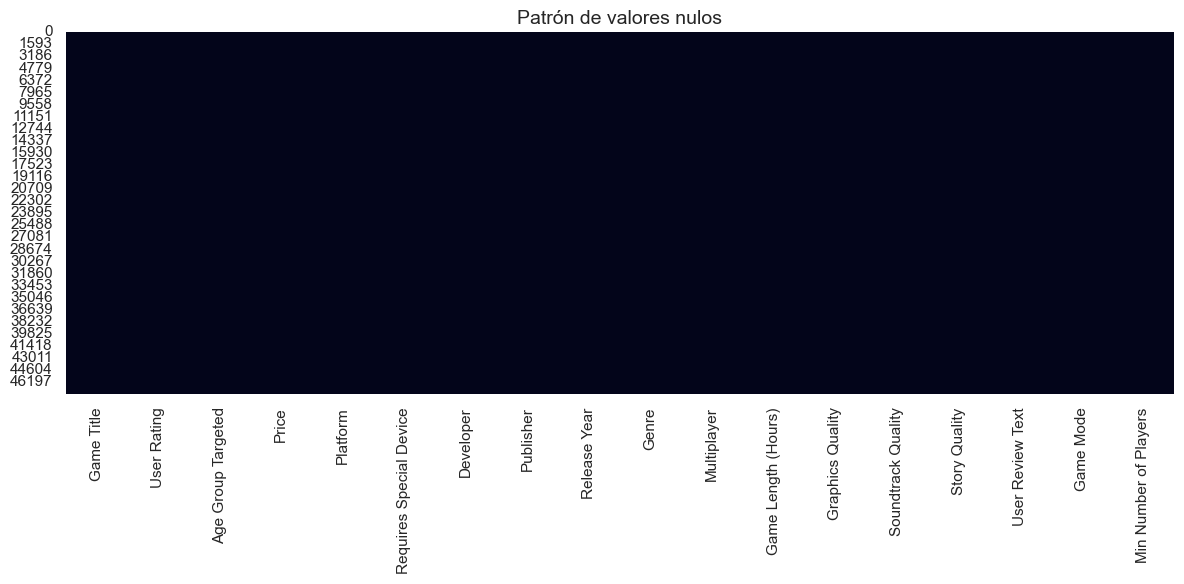


Cheques básicos para Price -> min=19.99, max=59.99
Filas con valores fuera de rango o no numéricos en Price: 0 (mostrando hasta 5)


,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players



Cheques básicos para Release Year -> min=2010, max=2023
Filas con valores fuera de rango o no numéricos en Release Year: 0 (mostrando hasta 5)


,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players



Cheques básicos para User Rating -> min=10.1, max=49.5
Filas con valores fuera de rango o no numéricos en User Rating: 47774 (mostrando hasta 5)


,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1



Cheques básicos para Min Number of Players -> min=1, max=10
Filas con valores fuera de rango o no numéricos en Min Number of Players: 0 (mostrando hasta 5)


,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players


Filas eliminadas por año fuera de rango: 0

Dimensiones después de limpieza preliminar: (47774, 19)


In [6]:
# Duplicados
subset_keys = []
if name_cols["game_title"] is not None:
    subset_keys.append(name_cols["game_title"])
if name_cols["release_year"] is not None:
    subset_keys.append(name_cols["release_year"])

full_dups = df.duplicated(keep=False).sum()
print(f"Duplicados (todas las columnas): {full_dups}")

if subset_keys:
    key_dups = df.duplicated(subset=subset_keys, keep=False).sum()
    print(f"Duplicados por {subset_keys}: {key_dups}")
else:
    print("No se encontraron columnas clave para duplicados por título+año.")

# Nulos
null_counts = df.isnull().sum().sort_values(ascending=False)
print("\nNulos por columna:")
display(null_counts)

# Heatmap de nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Patrón de valores nulos")
save_fig(OUTPUT_DIR / "b_nulls_heatmap.png")
plt.show()

# Valores inválidos y outliers lógicos
checks = {
    "price": (name_cols["price"], -1, 10000),
    "release_year": (name_cols["release_year"], 1970, CURRENT_YEAR + 1),
    "user_rating": (name_cols["user_rating"], 0, 10),
    "min_players": (name_cols["min_players"], 1, 128),
}

for label, (col, vmin, vmax) in checks.items():
    if col is None or col not in df.columns:
        print(f"Columna no disponible para chequeo: {label}")
        continue
    series = pd.to_numeric(df[col], errors='coerce')
    print(f"\nCheques básicos para {col} -> min={series.min()}, max={series.max()}")
    invalid = df[(series < vmin) | (series > vmax) | series.isna()]
    print(f"Filas con valores fuera de rango o no numéricos en {col}: {len(invalid)} (mostrando hasta 5)")
    display(invalid.head(5))

# Decisiones básicas (documentadas):
# - Eliminar filas con Release Year < 1970 o > CURRENT_YEAR+1
# - Para Price negativo, imputar 0 (asume dato erróneo) y marcar flag
# - Para User Rating fuera [0,10], setear NaN (para no introducir sesgo)
# - Para Min Players <1, setear NaN

clean_df = df.copy(deep=True)
flags = {}

# Year fuera de rango -> eliminar
year_col = name_cols["release_year"]
if year_col is not None:
    before = len(clean_df)
    clean_df = clean_df[(pd.to_numeric(clean_df[year_col], errors='coerce') >= 1970) &
                        (pd.to_numeric(clean_df[year_col], errors='coerce') <= CURRENT_YEAR + 1)]
    print(f"Filas eliminadas por año fuera de rango: {before - len(clean_df)}")

# Price negativo -> 0 y flag
price_col = name_cols["price"]
if price_col is not None:
    price_num = pd.to_numeric(clean_df[price_col], errors='coerce')
    flags['price_was_negative'] = (price_num < 0).astype(int)
    clean_df[price_col] = np.where(price_num < 0, 0, price_num)

# User rating fuera de rango -> NaN
rating_col = name_cols["user_rating"]
if rating_col is not None:
    rating_num = pd.to_numeric(clean_df[rating_col], errors='coerce')
    clean_df[rating_col] = rating_num.where((rating_num >= 0) & (rating_num <= 10), np.nan)

# Min players <1 -> NaN
minp_col = name_cols["min_players"]
if minp_col is not None:
    minp_num = pd.to_numeric(clean_df[minp_col], errors='coerce')
    clean_df[minp_col] = minp_num.where(minp_num >= 1, np.nan)

# Añadir flags si se generaron
for k, v in flags.items():
    clean_df[k] = v

print("\nDimensiones después de limpieza preliminar:", clean_df.shape)


## C. Análisis univariado

Exploramos la distribución de variables numéricas y categóricas, detectamos outliers via IQR y mapeamos ordinales a numérico.


User Rating: serie vacía tras dropna(); se omiten histogramas/boxplot.
Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_dist_Price.png


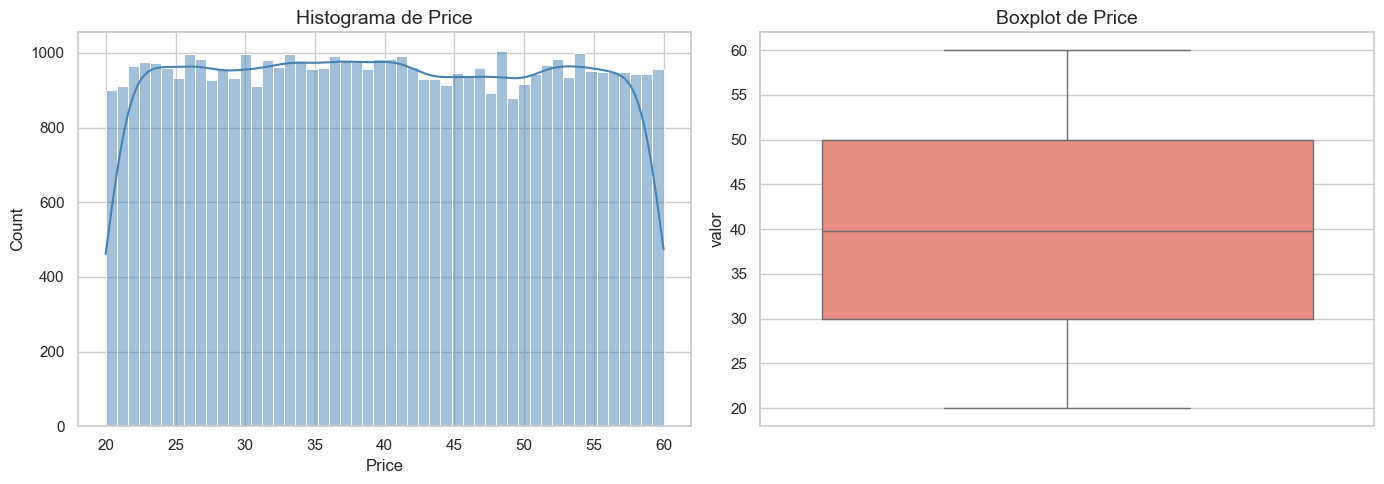

mean        39.951371
median      39.845000
std         11.520342
skew         0.011234
kurtosis    -1.196651
p1          20.410000
p5          22.050000
p25         29.990000
p50         39.845000
p75         49.957500
p95         57.970000
p99         59.590000
Name: stats_Price, dtype: float64

Top 10 outliers (|IQR|) en Price:


,Price


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_dist_Game Length (Hours).png


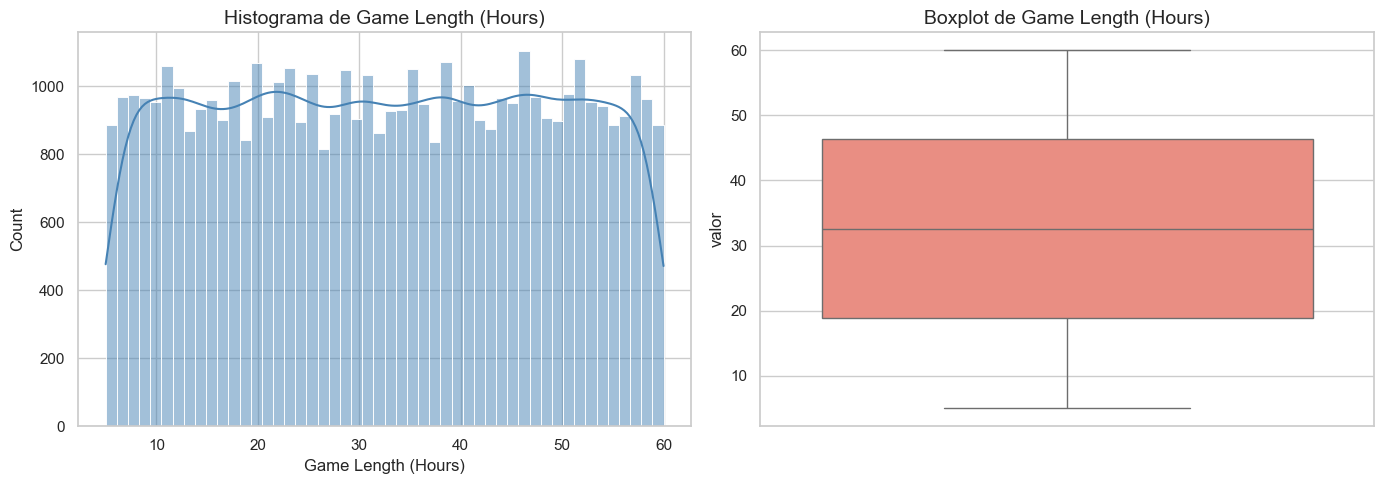

mean        32.481672
median      32.500000
std         15.872508
skew        -0.001306
kurtosis    -1.202125
p1           5.500000
p5           7.800000
p25         18.800000
p50         32.500000
p75         46.300000
p95         57.200000
p99         59.400000
Name: stats_Game Length (Hours), dtype: float64

Top 10 outliers (|IQR|) en Game Length (Hours):


,Game Length (Hours)


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_dist_Min Number of Players.png


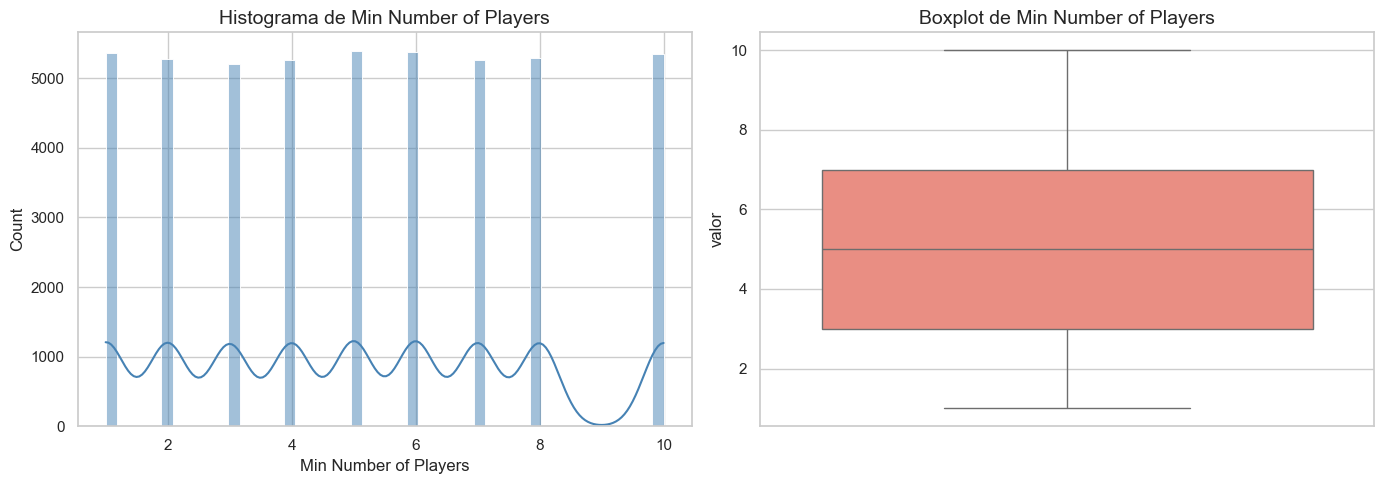

mean         5.116758
median       5.000000
std          2.769521
skew         0.195232
kurtosis    -0.998313
p1           1.000000
p5           1.000000
p25          3.000000
p50          5.000000
p75          7.000000
p95         10.000000
p99         10.000000
Name: stats_Min Number of Players, dtype: float64

Top 10 outliers (|IQR|) en Min Number of Players:


,Min Number of Players


Platform
PlayStation        9633
PC                 9599
Nintendo Switch    9596
Mobile             9589
Xbox               9357
Name: count, dtype: int64

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, orient='h', palette='viridis')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_freq_Platform.png


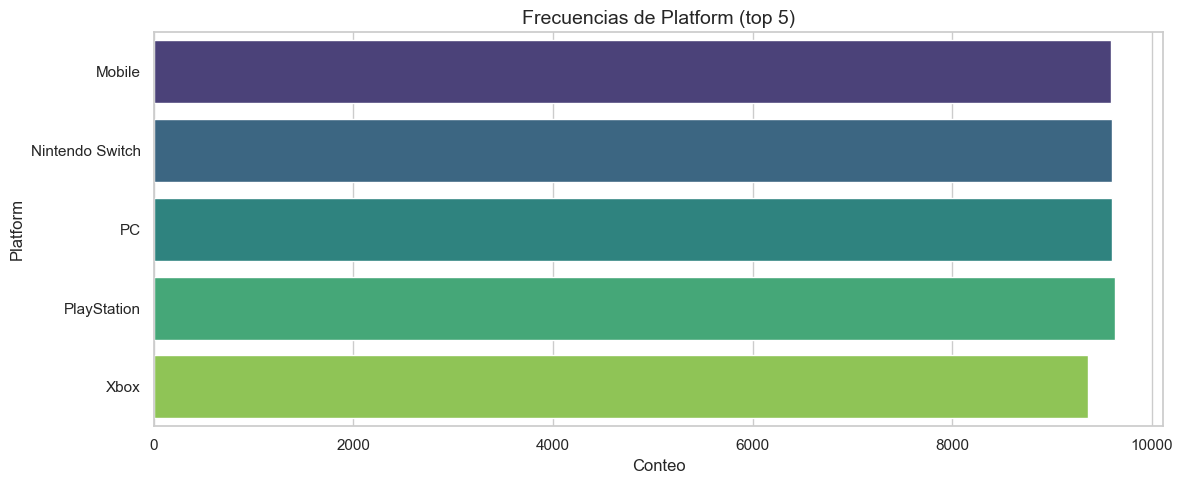

Genre
RPG           4873
Shooter       4869
Strategy      4867
Puzzle        4822
Simulation    4784
Adventure     4750
Party         4748
Sports        4735
Fighting      4687
Action        4639
Name: count, dtype: int64

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, orient='h', palette='viridis')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_freq_Genre.png


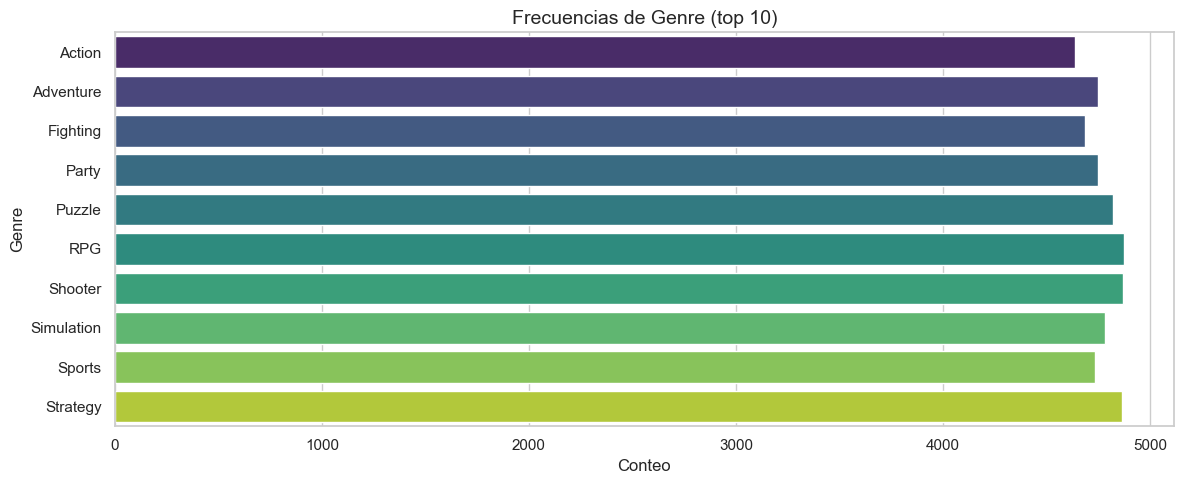

Multiplayer
No     24090
Yes    23684
Name: count, dtype: int64

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, orient='h', palette='viridis')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_freq_Multiplayer.png


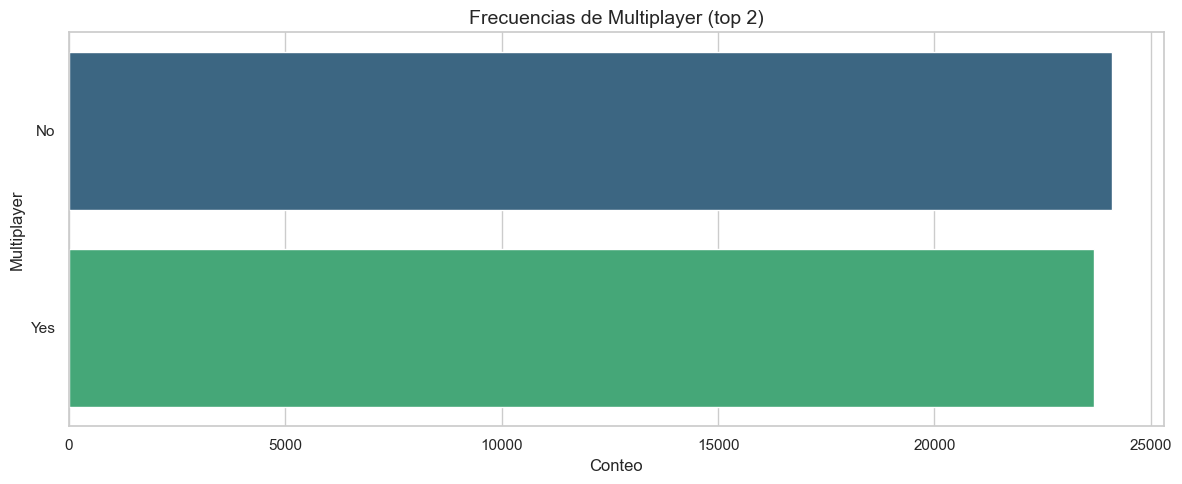

Graphics Quality
High      12113
Medium    12040
Ultra     11811
Low       11810
Name: count, dtype: int64

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, orient='h', palette='viridis')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_freq_Graphics Quality.png


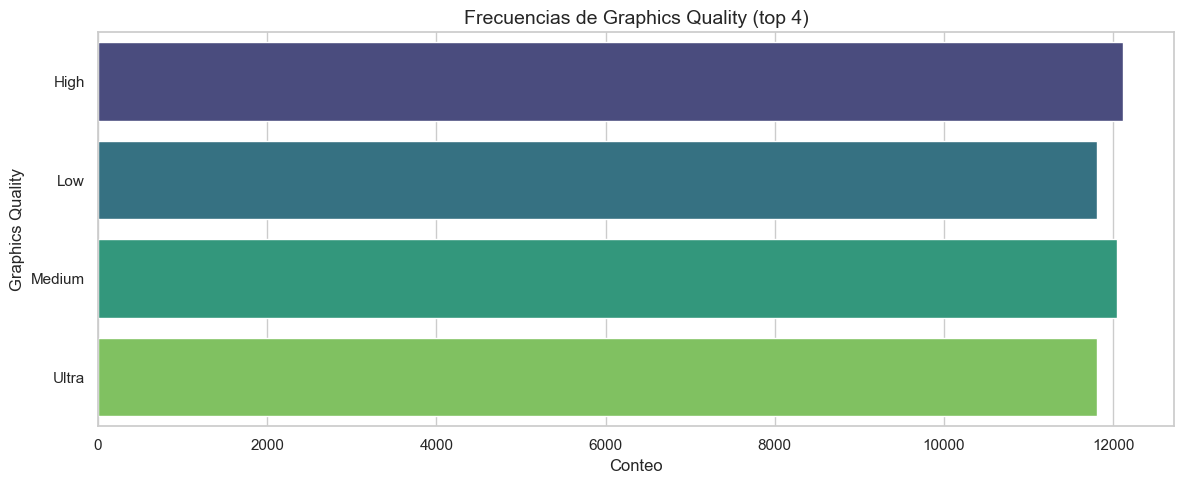

Soundtrack Quality
Excellent    12036
Good         11985
Average      11952
Poor         11801
Name: count, dtype: int64

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, orient='h', palette='viridis')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_freq_Soundtrack Quality.png


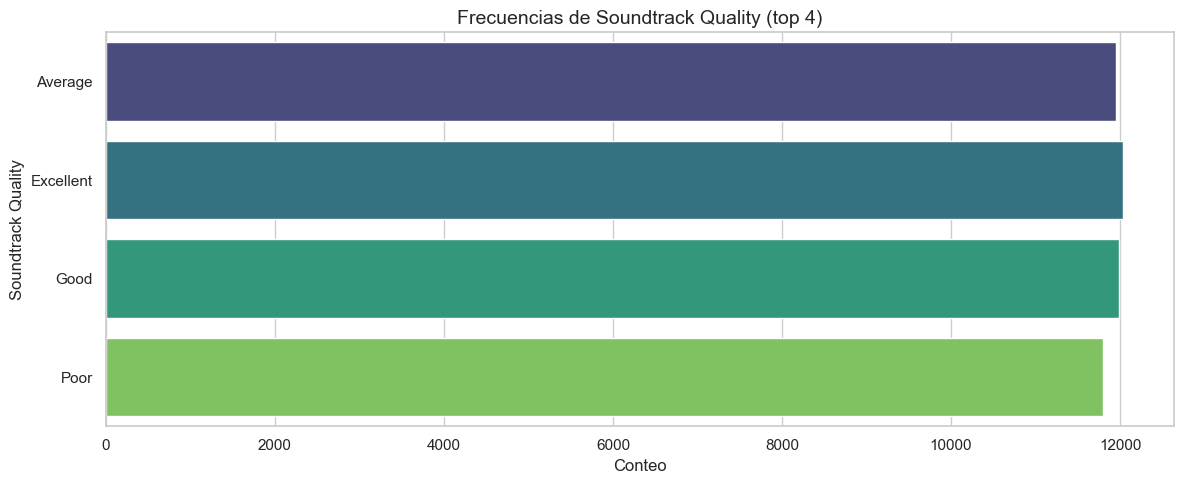

Story Quality
Poor         12041
Excellent    11987
Average      11919
Good         11827
Name: count, dtype: int64

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, orient='h', palette='viridis')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_freq_Story Quality.png


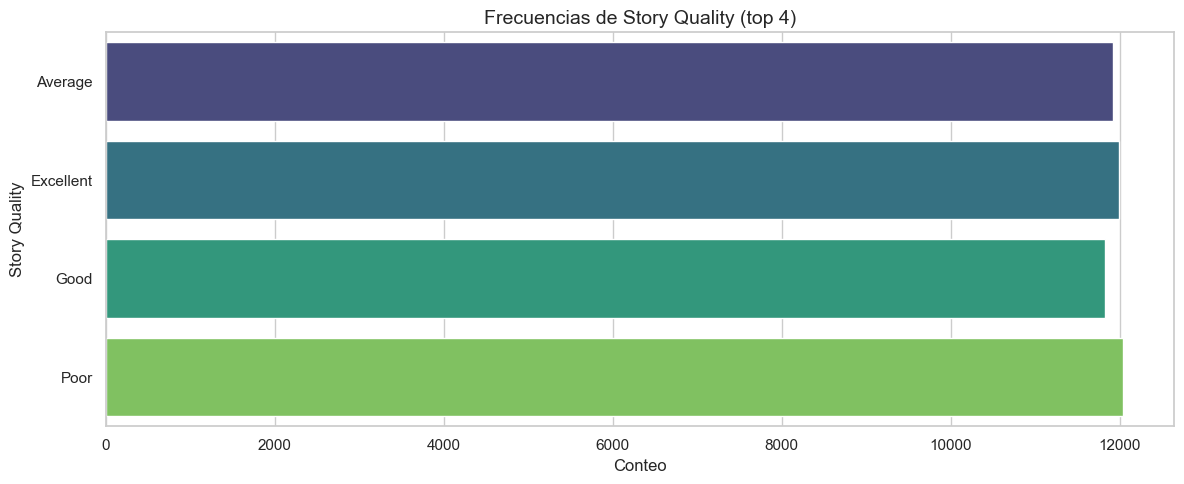

Game Mode
Offline    23957
Online     23817
Name: count, dtype: int64

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, orient='h', palette='viridis')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_freq_Game Mode.png


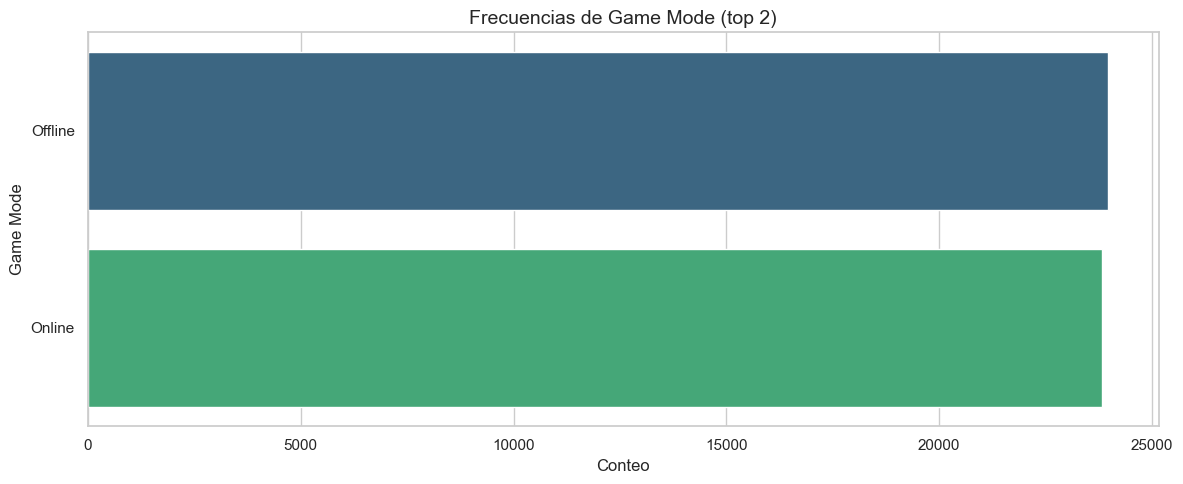

Requires Special Device
No     23887
Yes    23887
Name: count, dtype: int64

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.values, y=top_values.index, orient='h', palette='viridis')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_freq_Requires Special Device.png


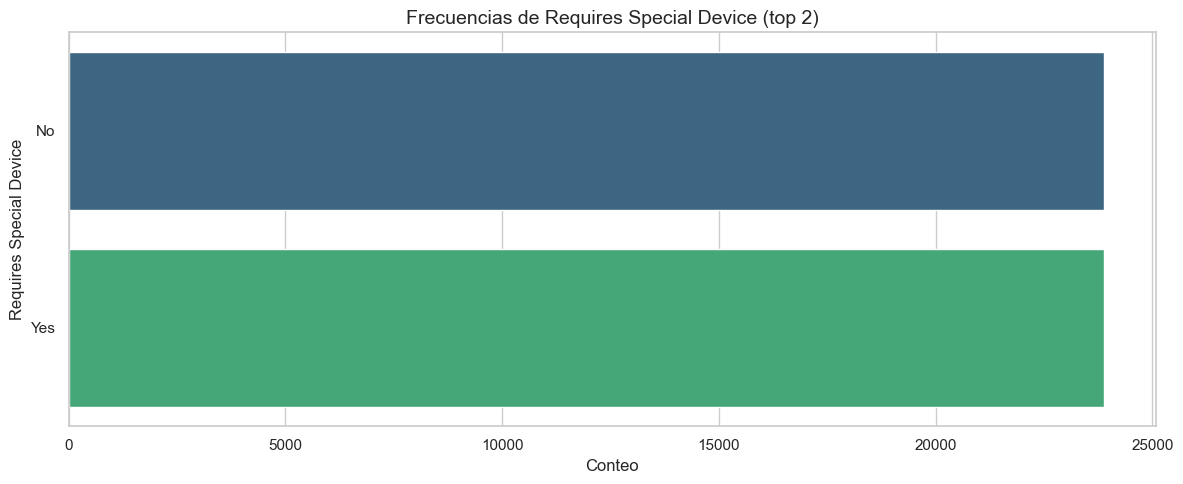

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_col, data=clean_df, palette='Set2')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_ord_Graphics Quality.png


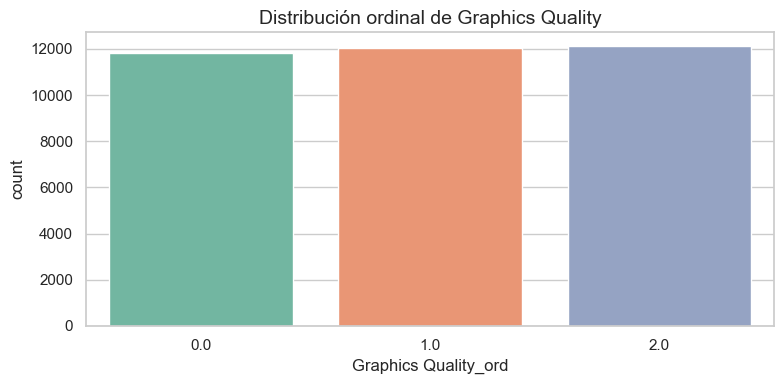

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_col, data=clean_df, palette='Set2')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_ord_Soundtrack Quality.png


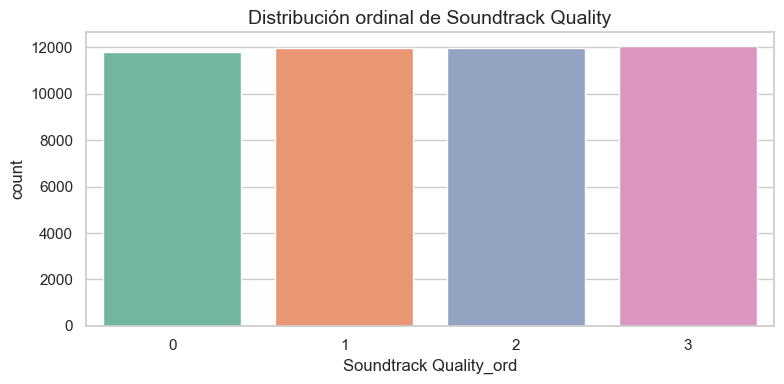

C:\Users\marti\AppData\Local\Temp\ipykernel_14796\2436535607.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=new_col, data=clean_df, palette='Set2')


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\c_ord_Story Quality.png


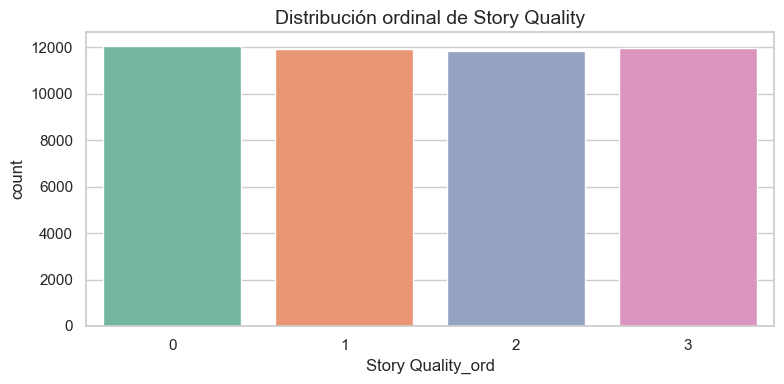

In [7]:
# Variables numéricas: histogramas y boxplots
num_candidates = [name_cols["user_rating"], name_cols["price"], name_cols["game_length"], name_cols["min_players"]]
num_cols = [c for c in num_candidates if c is not None and c in clean_df.columns]

for col in num_cols:
    series = pd.to_numeric(clean_df[col], errors='coerce')
    series_no_na = series.dropna()
    if series_no_na.empty:
        print(f"{col}: serie vacía tras dropna(); se omiten histogramas/boxplot.")
        continue
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(series_no_na, bins=50, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f"Histograma de {col}")
    # Usar DataFrame explícito para evitar problemas de posiciones en seaborn
    df_box = pd.DataFrame({"valor": series_no_na.values})
    sns.boxplot(data=df_box, y="valor", ax=axes[1], color='salmon')
    axes[1].set_title(f"Boxplot de {col}")
    save_fig(OUTPUT_DIR / f"c_dist_{col}.png")
    plt.show()

    stats_dict = {
        'mean': series.mean(),
        'median': series.median(),
        'std': series.std(),
        'skew': series.skew(),
        'kurtosis': series.kurtosis(),
        'p1': series.quantile(0.01),
        'p5': series.quantile(0.05),
        'p25': series.quantile(0.25),
        'p50': series.quantile(0.50),
        'p75': series.quantile(0.75),
        'p95': series.quantile(0.95),
        'p99': series.quantile(0.99),
    }
    display(pd.Series(stats_dict, name=f"stats_{col}"))

    # Outliers vía IQR
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_idx = series[(series < lower) | (series > upper)].sort_values(ascending=False).index
    print(f"Top 10 outliers (|IQR|) en {col}:")
    display(clean_df.loc[outlier_idx, [col]].head(10))

# Variables categóricas: frecuencias y barras
cat_candidates = [name_cols["platform"], name_cols["genre"], name_cols["multiplayer"],
                  name_cols["graphics"], name_cols["soundtrack"], name_cols["story"],
                  name_cols["game_mode"], name_cols["special_device"]]
cat_cols = [c for c in cat_candidates if c is not None and c in clean_df.columns]

for col in cat_cols:
    freq = clean_df[col].astype('category').value_counts(dropna=False)
    display(freq.head(50))
    plt.figure(figsize=(12, 5))
    top_values = freq.head(min(20, len(freq)))
    sns.barplot(x=top_values.values, y=top_values.index, orient='h', palette='viridis')
    plt.title(f"Frecuencias de {col} (top {len(top_values)})")
    plt.xlabel("Conteo")
    plt.ylabel(col)
    save_fig(OUTPUT_DIR / f"c_freq_{col}.png")
    plt.show()

# Mapear ordinales
ordinal_maps = {
    'Poor': 0, 'Bad': 0, 'Low': 0,
    'Average': 1, 'Fair': 1, 'Medium': 1,
    'Good': 2, 'High': 2,
    'Excellent': 3, 'Very Good': 3, 'Top': 3
}

for key in ["graphics", "soundtrack", "story"]:
    col = name_cols[key]
    if col is not None and col in clean_df.columns:
        new_col = f"{col}_ord"
        clean_df[new_col] = clean_df[col].map(ordinal_maps)
        plt.figure(figsize=(8, 4))
        sns.countplot(x=new_col, data=clean_df, palette='Set2')
        plt.title(f"Distribución ordinal de {col}")
        save_fig(OUTPUT_DIR / f"c_ord_{col}.png")
        plt.show()



## D. Tratamiento de Genre (multi-etiqueta) y cardinalidad alta

Parseamos `Genre` a listas, creamos `n_genres`, dummies para top géneros y agrupaciones para columnas de alta cardinalidad como `Developer` y `Publisher`. Documentamos el criterio de selección (top-15 por frecuencia para géneros, top-30 para desarrolladores/publicadores).


RPG           4873
Shooter       4869
Strategy      4867
Puzzle        4822
Simulation    4784
Adventure     4750
Party         4748
Sports        4735
Fighting      4687
Action        4639
dtype: int64

Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\d_top20_genres.png


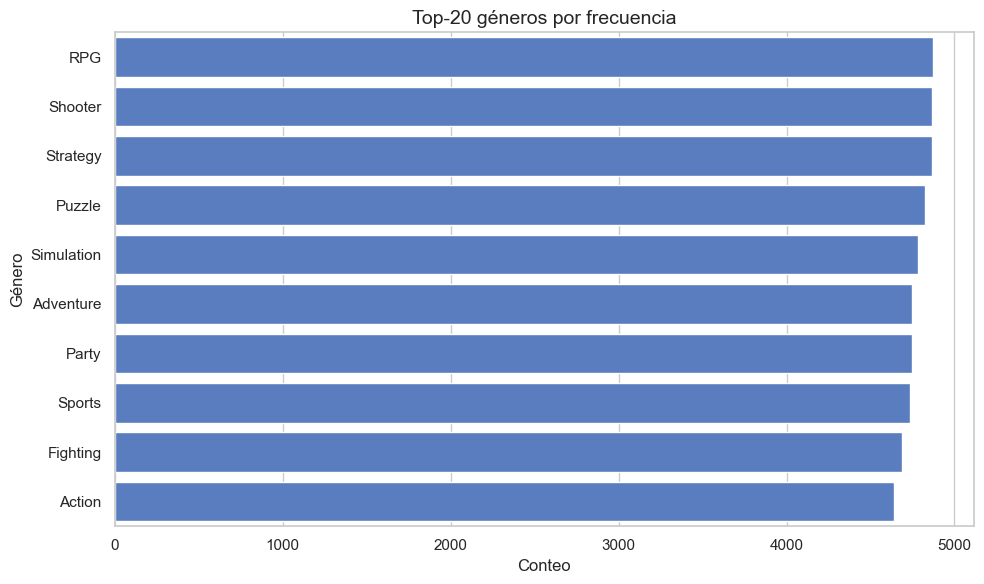

Developer
Bungie            4877
Game Freak        4876
Epic Games        4845
EA Sports         4826
Capcom            4826
Innersloth        4747
Rockstar Games    4736
Valve             4717
CD Projekt Red    4696
Nintendo          4628
Name: count, dtype: int64

Cobertura de top-30 en Developer: 100.0%
Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\d_top_developer.png


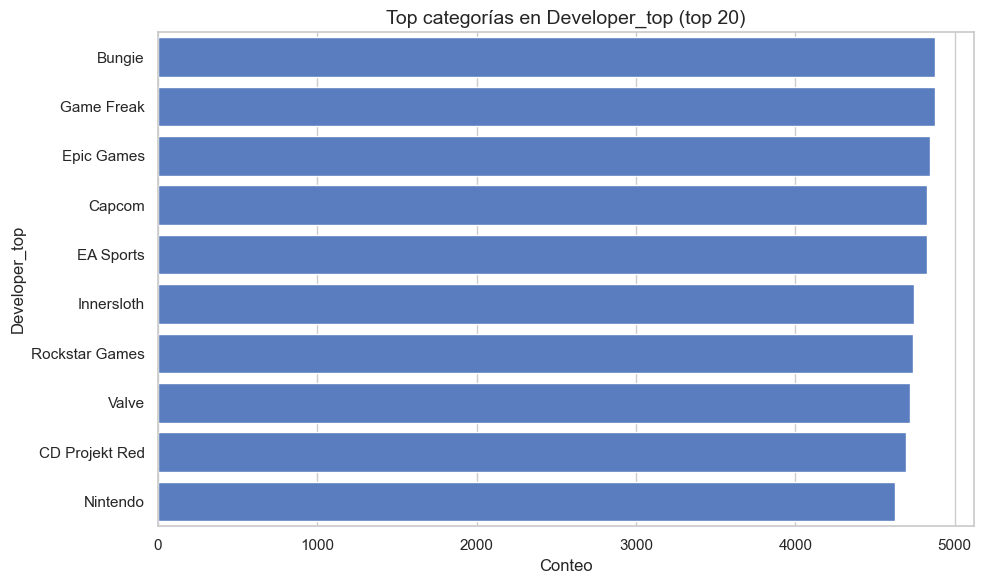

Publisher
Capcom                  5406
Electronic Arts         5382
Activision              5360
Epic Games              5353
Valve                   5316
Take-Two Interactive    5269
Square Enix             5262
Nintendo                5226
Innersloth              5200
Name: count, dtype: int64

Cobertura de top-30 en Publisher: 100.0%
Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\d_top_publisher.png


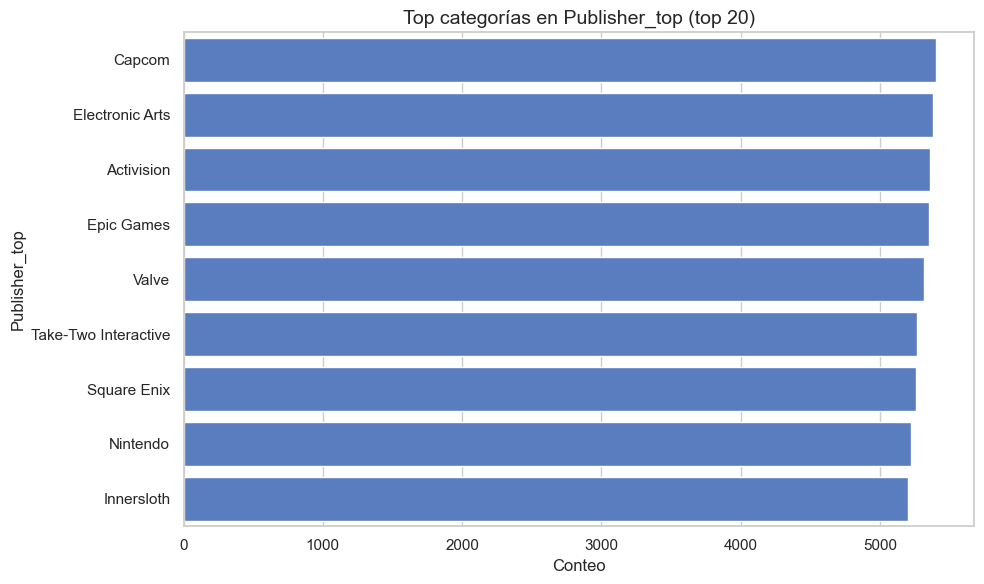

In [8]:
# Parseo de géneros
if name_cols["genre"] is not None and name_cols["genre"] in clean_df.columns:
    genre_col = name_cols["genre"]
    def split_genres(x):
        if pd.isna(x):
            return []
        if isinstance(x, str):
            return [g.strip() for g in x.split(',') if g.strip()]
        return []

    clean_df["genres_list"] = clean_df[genre_col].apply(split_genres)
    clean_df["n_genres"] = clean_df["genres_list"].apply(len)

    # Top-20 géneros por frecuencia total
    from collections import Counter
    genre_counter = Counter(g for lst in clean_df["genres_list"] for g in lst)
    genre_freq = pd.Series(dict(genre_counter)).sort_values(ascending=False)
    display(genre_freq.head(20))

    # Seleccionar top-15 para columnas binarias
    top_k = min(15, len(genre_freq))
    top_genres = list(genre_freq.head(top_k).index)
    for g in top_genres:
        clean_df[f"genre_{g.replace(' ', '_').lower()}"] = clean_df["genres_list"].apply(lambda lst, gx=g: int(gx in lst))

    # Figura de top-20
    plt.figure(figsize=(10, 6))
    sns.barplot(x=genre_freq.head(20).values, y=genre_freq.head(20).index, orient='h')
    plt.title("Top-20 géneros por frecuencia")
    plt.xlabel("Conteo")
    plt.ylabel("Género")
    save_fig(OUTPUT_DIR / "d_top20_genres.png")
    plt.show()
else:
    print("Columna de género no disponible; se omite procesamiento de géneros.")

# Alta cardinalidad: Developer y Publisher
for key, K in [("developer", 30), ("publisher", 30)]:
    col = name_cols[key]
    if col is None or col not in clean_df.columns:
        print(f"Columna no disponible: {key}")
        continue
    freq = clean_df[col].astype('category').value_counts()
    display(freq.head(20))
    top_k_values = set(freq.head(K).index)
    new_col = f"{col}_top"
    clean_df[new_col] = clean_df[col].where(clean_df[col].isin(top_k_values), other="Other")

    coverage = clean_df[new_col].ne("Other").mean()
    print(f"Cobertura de top-{K} en {col}: {coverage:.1%}")

    plt.figure(figsize=(10, 6))
    top_plot = clean_df[new_col].value_counts().head(20)
    sns.barplot(x=top_plot.values, y=top_plot.index, orient='h')
    plt.title(f"Top categorías en {new_col} (top 20)")
    plt.xlabel("Conteo")
    plt.ylabel(new_col)
    save_fig(OUTPUT_DIR / f"d_top_{key}.png")
    plt.show()



## E. Feature engineering ligero (solo EDA)

Creamos `age_since_release` y métricas simples del texto (`User Review Text`). Generamos TF-IDF (1–2-gramas, max_features=20000) y reducimos con SVD a 20 componentes (se añaden 5 primeras como `text_svd_0..4`). Nota: TF-IDF puede ser costoso en memoria; ajustar `max_features` si falla.


In [9]:
# Edad desde lanzamiento
if name_cols["release_year"] is not None and name_cols["release_year"] in clean_df.columns:
    clean_df["age_since_release"] = CURRENT_YEAR - pd.to_numeric(clean_df[name_cols["release_year"]], errors='coerce')

# Métricas de texto
review_col = name_cols["review_text"]
if review_col is not None and review_col in clean_df.columns:
    txt = clean_df[review_col].fillna("")
    clean_df["review_length"] = txt.astype(str).apply(len)
    clean_df["review_word_count"] = txt.astype(str).apply(lambda s: len(s.split()))
    clean_df["review_exclaims"] = txt.astype(str).apply(lambda s: s.count('!'))
    def allcaps_ratio(s: str):
        tokens = [t for t in s.split() if t.isalpha()]
        if not tokens:
            return 0.0
        caps = sum(1 for t in tokens if t.isupper() and len(t) > 1)
        return caps / len(tokens)
    clean_df["review_allcaps_ratio"] = txt.astype(str).apply(allcaps_ratio)
else:
    print("No hay texto de reseñas disponible; se omiten métricas de texto.")

# TF-IDF + SVD
TFIDF_MAX_FEATURES = 20000
SVD_COMPONENTS = 20

if review_col is not None and review_col in clean_df.columns:
    try:
        vectorizer = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES,
                                     ngram_range=(1, 2),
                                     stop_words='english')
        tfidf_matrix = vectorizer.fit_transform(clean_df[review_col].fillna("").astype(str))
        print(f"TF-IDF shape: {tfidf_matrix.shape}")

        svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
        tfidf_svd = svd.fit_transform(tfidf_matrix)
        print(f"SVD shape: {tfidf_svd.shape}")

        for i in range(5):
            clean_df[f"text_svd_{i}"] = tfidf_svd[:, i]

        # Visual rápido de dos componentes
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=clean_df["text_svd_0"], y=clean_df["text_svd_1"], s=12, alpha=0.5)
        plt.title("Espacio SVD de TF-IDF (comp 0 vs 1)")
        plt.xlabel("text_svd_0")
        plt.ylabel("text_svd_1")
        save_fig(OUTPUT_DIR / "e_tfidf_svd_scatter.png")
        plt.show()
    except MemoryError:
        warnings.warn("TF-IDF excedió memoria. Reduce max_features o muestrea.")
    except Exception as e:
        warnings.warn(f"Fallo TF-IDF/SVD: {e}")
else:
    print("TF-IDF no aplicado por ausencia de columna de texto.")


TF-IDF shape: (47774, 18)


C:\Users\marti\AppData\Local\Temp\ipykernel_14796\1795083649.py:52: UserWarning: Fallo TF-IDF/SVD: n_components(20) must be <= n_features(18).
  warnings.warn(f"Fallo TF-IDF/SVD: {e}")


## F. Análisis bivariado y relación con User Rating

Correlaciones entre variables numéricas, scatter/hexbin con el target y boxplots por categorías relevantes (Platform, Multiplayer, ordinales, géneros top). Estadística descriptiva por `Developer_top` y `Publisher_top`.


Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\f_corr_heatmap.png


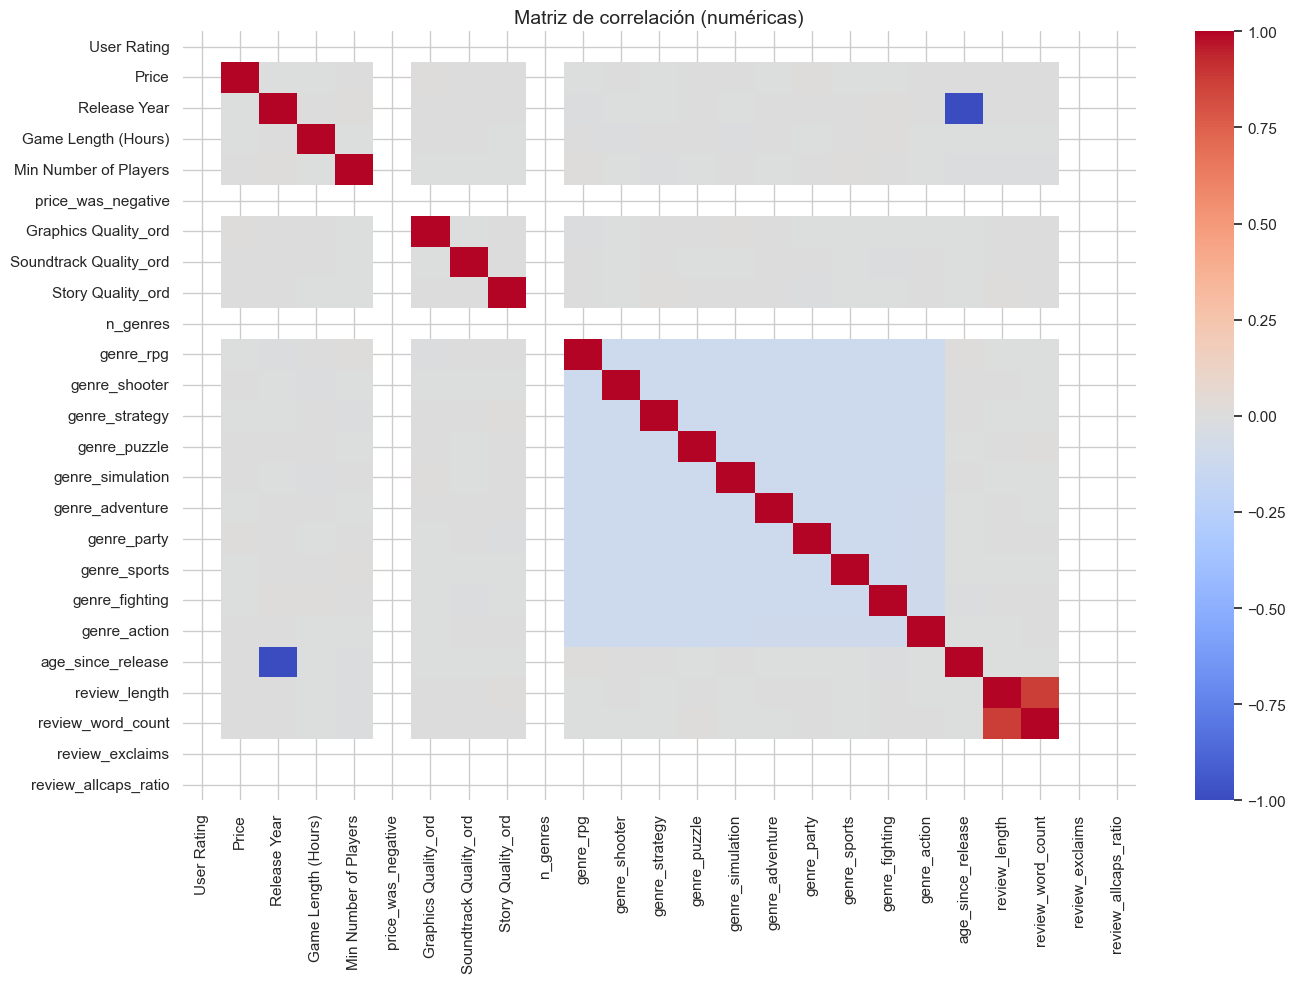

Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\f_scatter_User Rating_vs_Price.png


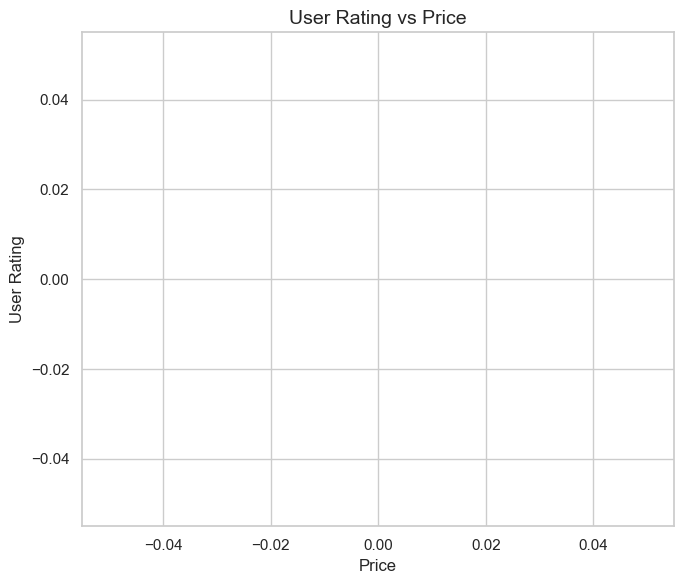

Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\f_hexbin_User Rating_vs_Price.png


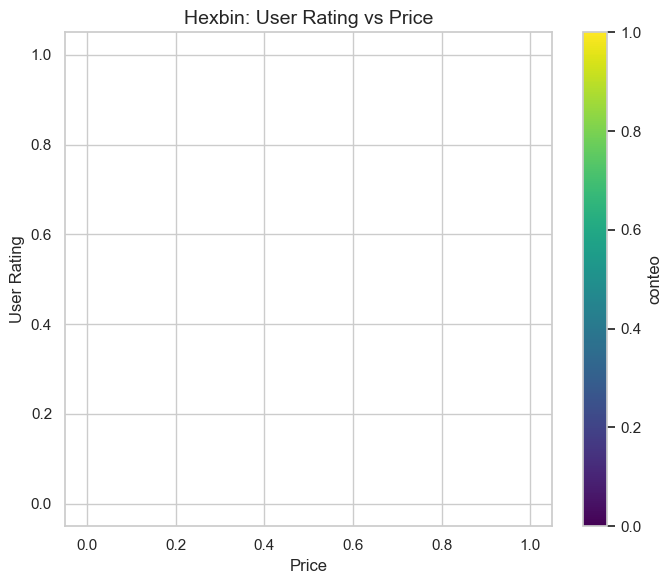

Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\f_scatter_User Rating_vs_Game Length (Hours).png


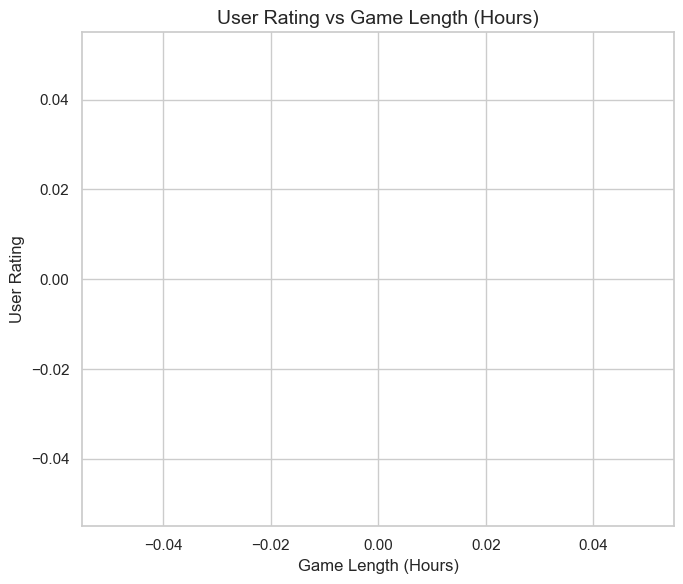

Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\f_hexbin_User Rating_vs_Game Length (Hours).png


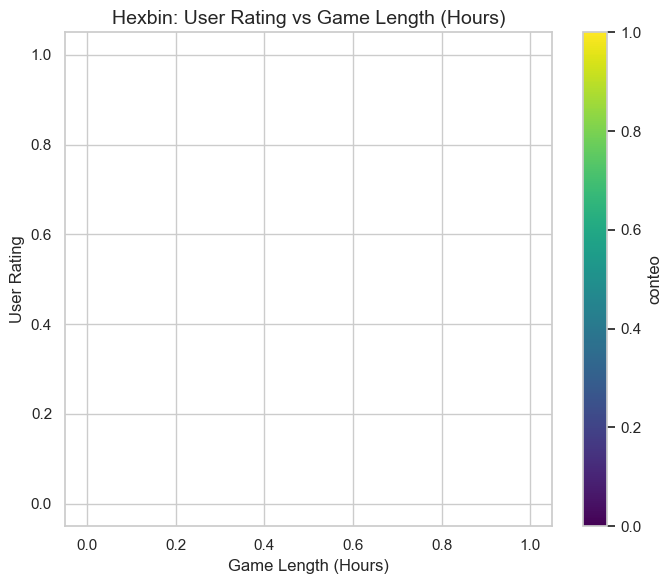

Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\f_scatter_User Rating_vs_age_since_release.png


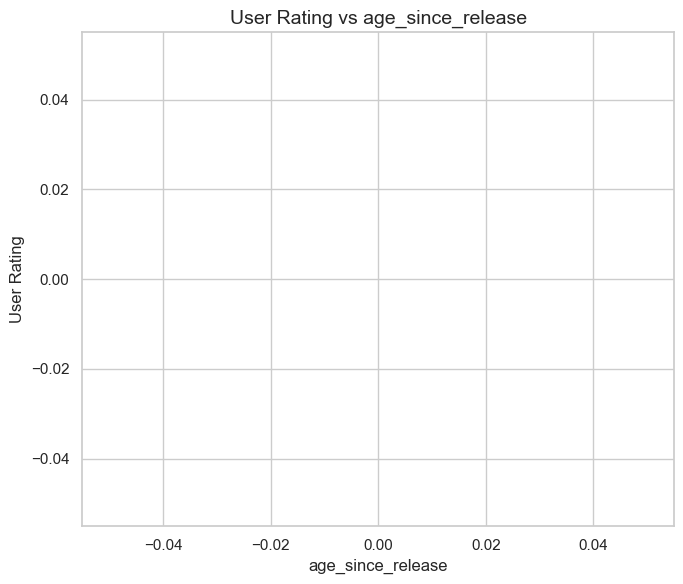

Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\f_hexbin_User Rating_vs_age_since_release.png


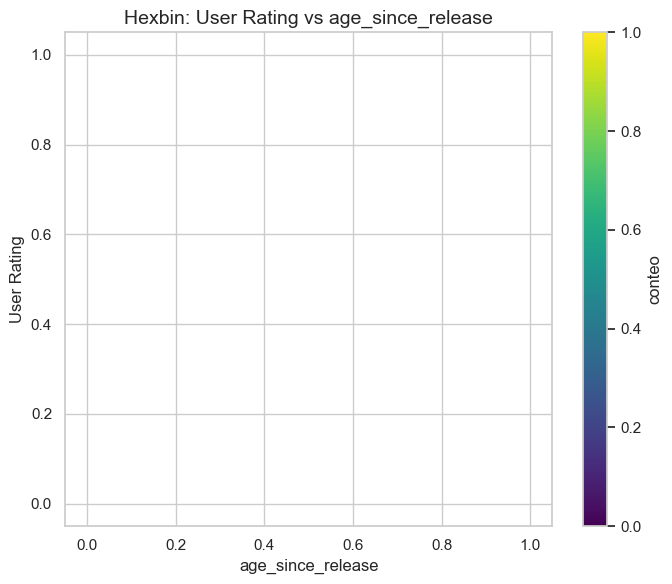

Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\f_scatter_User Rating_vs_review_length.png


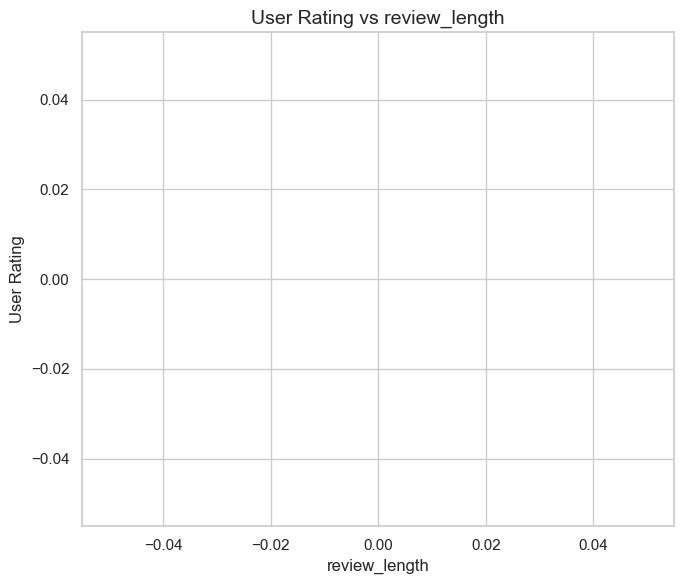

Figura guardada: c:\Users\marti\OneDrive\Documents\Diego\8VO SEMESTRE\INTRO A IA\PROYECTO 4\proyecto4_IA\EDA\eda_figures\f_hexbin_User Rating_vs_review_length.png


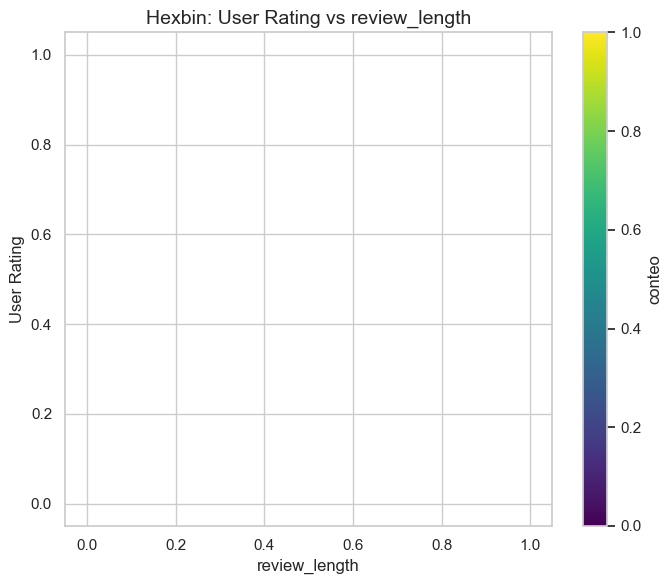

ValueError: List of boxplot statistics and `positions` values must have same the length

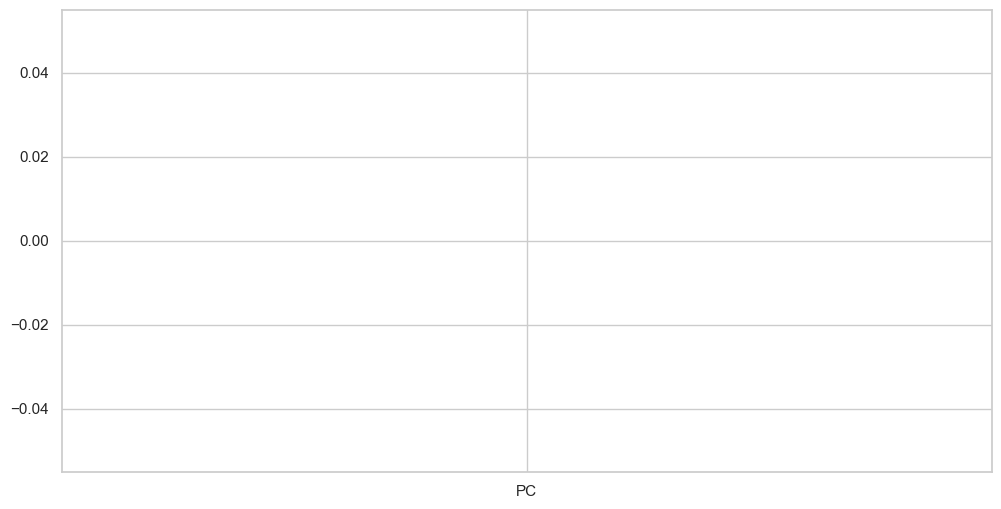

In [10]:
# Matriz de correlación (incluye ordinales y SVD si existen)
num_for_corr = []
for c in clean_df.columns:
    if pd.api.types.is_numeric_dtype(clean_df[c]):
        num_for_corr.append(c)

corr = clean_df[num_for_corr].corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Matriz de correlación (numéricas)")
save_fig(OUTPUT_DIR / "f_corr_heatmap.png")
plt.show()

# Scatterplots/Hexbin con User Rating
ur = name_cols["user_rating"]
scatter_candidates = [name_cols["price"], name_cols["game_length"], "age_since_release", "review_length"]
for col in [c for c in scatter_candidates if c is not None and c in clean_df.columns and ur is not None]:
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=clean_df[col], y=clean_df[ur], alpha=0.4, s=18)
    plt.title(f"{ur} vs {col}")
    plt.xlabel(col)
    plt.ylabel(ur)
    save_fig(OUTPUT_DIR / f"f_scatter_{ur}_vs_{col}.png")
    plt.show()

    plt.figure(figsize=(7, 6))
    plt.hexbin(clean_df[col], clean_df[ur], gridsize=40, cmap='viridis', mincnt=1)
    plt.colorbar(label='conteo')
    plt.title(f"Hexbin: {ur} vs {col}")
    plt.xlabel(col)
    plt.ylabel(ur)
    save_fig(OUTPUT_DIR / f"f_hexbin_{ur}_vs_{col}.png")
    plt.show()

# Boxplots por categorías
cat_for_box = [name_cols["platform"], name_cols["multiplayer"]]
for ord_key in ["graphics", "soundtrack", "story"]:
    col = name_cols[ord_key]
    if col is not None and f"{col}_ord" in clean_df.columns:
        cat_for_box.append(f"{col}_ord")

if ur is not None:
    for col in [c for c in cat_for_box if c is not None and c in clean_df.columns]:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=col, y=ur, data=clean_df)
        plt.title(f"Distribución de {ur} por {col}")
        save_fig(OUTPUT_DIR / f"f_box_{ur}_by_{col}.png")
        plt.show()

# Boxplot por top géneros (si existen)
if ur is not None and "genres_list" in clean_df.columns:
    # Tomar top-10 géneros creados
    genre_cols = [c for c in clean_df.columns if c.startswith("genre_")]
    top10 = genre_cols[:10]
    for gcol in top10:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=gcol, y=ur, data=clean_df)
        plt.title(f"{ur} por {gcol}")
        save_fig(OUTPUT_DIR / f"f_box_{ur}_by_{gcol}.png")
        plt.show()

# Estadística descriptiva por Developer_top y Publisher_top
for key in ["developer", "publisher"]:
    col = name_cols[key]
    new_col = f"{col}_top" if col else None
    if ur is not None and new_col is not None and new_col in clean_df.columns:
        grp = clean_df.groupby(new_col)[ur].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
        display(grp.head(20))



## G. Análisis temporal

Serie temporal del `User Rating` promedio por año de lanzamiento con bandas de percentiles. Identificación de años con cambios bruscos.


In [ ]:
year_col = name_cols["release_year"]
ur = name_cols["user_rating"]

if year_col is not None and ur is not None:
    tmp = clean_df[[year_col, ur]].copy()
    tmp[year_col] = pd.to_numeric(tmp[year_col], errors='coerce')
    tmp = tmp.dropna(subset=[year_col, ur])
    grp = tmp.groupby(year_col)[ur].agg(['count', 'mean',
                                         lambda s: s.quantile(0.10),
                                         'median',
                                         lambda s: s.quantile(0.90)])
    grp.columns = ['count', 'mean', 'p10', 'median', 'p90']
    display(grp.tail(20))

    plt.figure(figsize=(12, 6))
    plt.plot(grp.index, grp['mean'], label='Promedio', color='steelblue')
    plt.fill_between(grp.index, grp['p10'], grp['p90'], color='steelblue', alpha=0.2, label='P10–P90')
    plt.title('User Rating promedio por año de lanzamiento')
    plt.xlabel('Año')
    plt.ylabel('User Rating')
    plt.legend()
    save_fig(OUTPUT_DIR / "g_time_series_rating.png")
    plt.show()

    # Cambios bruscos (diferencia año a año)
    grp['mean_diff'] = grp['mean'].diff()
    spikes = grp['mean_diff'].abs().sort_values(ascending=False).head(5)
    print("Años con mayores cambios interanuales en promedio de rating:")
    display(spikes)

    # Juegos representativos de años pico
    top_years = spikes.index.tolist()[:3]
    for y in top_years:
        sample = clean_df.loc[clean_df[year_col] == y]
        cols_show = [c for c in [name_cols["game_title"], ur, name_cols["platform"], name_cols["genre"]] if c is not None]
        print(f"\nJuegos representativos del año {y}:")
        display(sample[cols_show].head(10))
else:
    print("No hay columnas suficientes para análisis temporal.")


## H. Outliers y anomalías multivariadas

Usamos z-score para detectar casos simultáneamente extremos en múltiples columnas numéricas. Listamos los 20 principales sospechosos con columnas clave y texto de reseña.


In [ ]:
# Z-score multivariante
num_cols_all = [c for c in clean_df.columns if pd.api.types.is_numeric_dtype(clean_df[c])]

if len(num_cols_all) >= 2:
    z = np.abs(stats.zscore(clean_df[num_cols_all].fillna(clean_df[num_cols_all].median()), nan_policy='omit'))
    if isinstance(z, np.ndarray):
        zsum = np.nanmean(z, axis=1)
        clean_df["zsum_outlier_score"] = zsum
        suspects = clean_df.sort_values("zsum_outlier_score", ascending=False).head(20)
        cols_show = [c for c in [name_cols["game_title"], name_cols["user_rating"], name_cols["price"], name_cols["game_length"], name_cols["review_text"], "zsum_outlier_score"] if c is not None]
        display(suspects[cols_show])
    else:
        print("No se pudo calcular z-score adecuadamente.")
else:
    print("Insuficientes columnas numéricas para z-score multivariante.")

print("\nRecomendaciones (no se aplican automáticamente):")
print("- Revisar manualmente los 20 casos listados; validar si el dato es verosímil.")
print("- Si es claramente erróneo e irrecuperable, eliminar; si es recuperable, imputar.")
print("- Conservar outliers reales si aportan información sobre casos extremos.")


## I. Análisis de texto (EDA)

Frecuencias de unigrams y bigrams en `User Review Text` tras limpieza básica, distribución de `review_word_count` y relación `review_length` vs `User Rating`. Nube de palabras opcional (indicamos cómo generarla si no está instalada).


In [ ]:
# Frecuencias de unigrams y bigrams usando TfidfVectorizer como contador
review_col = name_cols["review_text"]
if review_col is not None and review_col in clean_df.columns:
    corpus = clean_df[review_col].fillna("").astype(str).str.lower()

    def get_top_ngrams(corpus, ngram_range=(1, 1), top_n=30):
        vec = TfidfVectorizer(ngram_range=ngram_range, stop_words='english', use_idf=False, norm=None)
        X = vec.fit_transform(corpus)
        freqs = np.asarray(X.sum(axis=0)).ravel()
        terms = np.array(vec.get_feature_names_out())
        order = np.argsort(freqs)[::-1]
        return pd.DataFrame({"ngram": terms[order][:top_n], "freq": freqs[order][:top_n]})

    top_uni = get_top_ngrams(corpus, (1, 1), 30)
    top_bi = get_top_ngrams(corpus, (2, 2), 30)
    print("Top 30 unigrams:")
    display(top_uni)
    print("Top 30 bigrams:")
    display(top_bi)

    # Distribución de review_word_count
    if "review_word_count" in clean_df.columns:
        plt.figure(figsize=(10, 5))
        sns.histplot(clean_df["review_word_count"], bins=50, kde=True)
        plt.title("Distribución de número de palabras en reseñas")
        plt.xlabel("Número de palabras")
        save_fig(OUTPUT_DIR / "i_review_word_count.png")
        plt.show()

    # Relación review_length vs User Rating
    ur = name_cols["user_rating"]
    if ur is not None:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=clean_df["review_length"], y=clean_df[ur], alpha=0.3, s=16)
        plt.title("Relación entre longitud de reseña y User Rating")
        plt.xlabel("Longitud de reseña (caracteres)")
        plt.ylabel("User Rating")
        save_fig(OUTPUT_DIR / "i_scatter_reviewlen_rating.png")
        plt.show()

    # Nube de palabras (opcional)
    try:
        from wordcloud import WordCloud
        text_concat = " ".join(corpus.tolist())
        wc = WordCloud(width=1000, height=600, background_color='white', stopwords=set()).generate(text_concat)
        plt.figure(figsize=(12, 7))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title("Nube de palabras (opcional)")
        save_fig(OUTPUT_DIR / "i_wordcloud.png")
        plt.show()
    except Exception:
        print("Nube de palabras no generada. Para incluirla: pip install wordcloud y re-ejecutar.")
else:
    print("No hay columna de texto de reseñas para análisis de texto.")


## J. Visualizaciones y reglas de estilo

Guardamos las 8 figuras más representativas: histograma del target, heatmap de correlación, boxplot por platform, serie temporal, top developers, distribución de price, review length, y scatter TF-IDF SVD.


In [ ]:
# Asegurar figuras clave (si no existen, recrearlas rápidamente)
ur = name_cols["user_rating"]
if ur is not None and ur in clean_df.columns:
    # 1. Histograma del target
    plt.figure(figsize=(8, 5))
    sns.histplot(pd.to_numeric(clean_df[ur], errors='coerce').dropna(), bins=50, kde=True)
    plt.title("Histograma de User Rating")
    save_fig(OUTPUT_DIR / "j_hist_user_rating.png")
    plt.show()

# 2. Heatmap de correlación ya guardado como f_corr_heatmap.png

# 3. Boxplot por Platform
if ur is not None and name_cols["platform"] is not None and name_cols["platform"] in clean_df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=name_cols["platform"], y=ur, data=clean_df)
    plt.title("User Rating por Platform")
    save_fig(OUTPUT_DIR / "j_box_platform.png")
    plt.show()

# 4. Serie temporal ya guardada como g_time_series_rating.png

# 5. Top developers (figura creada en D con d_top_developer.png)

# 6. Distribución de price
if name_cols["price"] is not None and name_cols["price"] in clean_df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(pd.to_numeric(clean_df[name_cols["price"]], errors='coerce').dropna(), bins=50, kde=True)
    plt.title("Distribución de Price")
    save_fig(OUTPUT_DIR / "j_hist_price.png")
    plt.show()

# 7. Review length
if "review_length" in clean_df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(clean_df["review_length"], bins=50, kde=True)
    plt.title("Distribución de longitud de reseña")
    save_fig(OUTPUT_DIR / "j_hist_review_length.png")
    plt.show()

# 8. Scatter TF-IDF SVD ya guardado como e_tfidf_svd_scatter.png

print("Figuras clave almacenadas en:", OUTPUT_DIR)


## K. Resumen final y guardado de artefactos

Guardamos `eda_snapshot_clean.csv` (con features creadas) y generamos `eda_summary.md` con hallazgos, columnas problemáticas, transformaciones y recomendaciones (solo pre-modelado).


In [ ]:
# Guardado de snapshot limpio y generación de resumen Markdown
lines = []

# Resumen ejecutivo (viñetas)
shape_original = df.shape
shape_clean = clean_df.shape
full_dups = df.duplicated(keep=False).sum()
subset_keys = []
if name_cols["game_title"] is not None:
    subset_keys.append(name_cols["game_title"])
if name_cols["release_year"] is not None:
    subset_keys.append(name_cols["release_year"])
key_dups = df.duplicated(subset=subset_keys, keep=False).sum() if subset_keys else 0
removed_by_year = len(df) - len(clean_df)

lines.append("# Resumen ejecutivo del EDA\n")
lines.append("- Dimensiones originales: {} filas x {} columnas.".format(*shape_original))
lines.append("- Dimensiones tras limpieza básica: {} filas x {} columnas.".format(*shape_clean))
lines.append(f"- Duplicados totales detectados: {full_dups}; por {subset_keys if subset_keys else 'N/A'}: {key_dups}.")

null_counts = df.isnull().sum().sort_values(ascending=False)
null_top = null_counts.head(5)
lines.append("- Columnas con más nulos (top-5): " + ", ".join([f"{k}: {v}" for k, v in null_top.items()]))

if name_cols["release_year"] is not None:
    lines.append(f"- Filas eliminadas por año fuera de rango: {removed_by_year}.")

# Cobertura top-K developer/publisher
for key, K in [("developer", 30), ("publisher", 30)]:
    col = name_cols[key]
    if col is not None and f"{col}_top" in clean_df.columns:
        coverage = clean_df[f"{col}_top"].ne("Other").mean()
        lines.append(f"- {key.title()} top-{K} cubre {coverage:.1%} de las filas.")

# Features creadas
created_feats = []
if "age_since_release" in clean_df.columns:
    created_feats.append("age_since_release")
for c in ["review_length", "review_word_count", "review_exclaims", "review_allcaps_ratio"]:
    if c in clean_df.columns:
        created_feats.append(c)
for i in range(5):
    col = f"text_svd_{i}"
    if col in clean_df.columns:
        created_feats.append(col)
if "n_genres" in clean_df.columns:
    created_feats.append("n_genres")
genre_cols = [c for c in clean_df.columns if c.startswith("genre_")]
created_feats += genre_cols
lines.append("- Features creadas: " + ", ".join(created_feats) if created_feats else "- No se crearon nuevas features.")

lines.append("\n---\n")
lines.append("## Columnas problemáticas y transformaciones aplicadas\n")
lines.append("- Años fuera de [1970, año_actual+1] eliminados.")
if name_cols["price"] is not None:
    lines.append("- Precios negativos imputados a 0 y marcado flag `price_was_negative`.")
if name_cols["user_rating"] is not None:
    lines.append("- `User Rating` fuera de [0,10] convertido a NaN (se mantiene para análisis descriptivo).")
if name_cols["min_players"] is not None:
    lines.append("- `Min Number of Players` < 1 convertido a NaN.")
lines.append("- Mapeo de ordinales (Graphics/Soundtrack/Story) a escala 0–3 cuando disponibles.")
lines.append("- Reducción de cardinalidad para `Developer` y `Publisher` creando `<col>_top` con top-30 + `Other`.")

lines.append("\n---\n")
lines.append("## Recomendaciones para la siguiente fase (pre-modelado)\n")
lines.append("- Conservar `User Rating`, variables ordinales mapeadas, `age_since_release`, métricas de texto y principales géneros.")
lines.append("- Evaluar tratamiento de nulos en `User Rating` (p.ej., exclusión en análisis dependientes del target).")
lines.append("- Profundizar limpieza de outliers identificados; validar datos de precio y duración extremos.")
lines.append("- Considerar codificar categorías de alta cardinalidad con técnicas adecuadas (no target encoding aún).")
lines.append("- Definir variantes de análisis con y sin texto si se requiere bajo costo computacional.")

lines.append("\n---\n")
lines.append("## Anexos\n")

# Tablas por Platform, Genre (top), Release Year
ur = name_cols["user_rating"]
annex_tables = {}
if ur is not None:
    if name_cols["platform"] is not None and name_cols["platform"] in clean_df.columns:
        annex_tables['platform'] = clean_df.groupby(name_cols["platform"]) [ur].agg(['count', 'mean', 'median']).sort_values('count', ascending=False).head(20)
    # Resumen por géneros binarios
    genre_stats = []
    for gcol in genre_cols[:20]:
        mask = clean_df[gcol] == 1
        if mask.sum() > 0:
            genre_stats.append({
                'genre': gcol.replace('genre_', '').replace('_', ' '),
                'count': int(mask.sum()),
                'mean': float(clean_df.loc[mask, ur].mean()),
                'median': float(clean_df.loc[mask, ur].median()),
            })
    if genre_stats:
        annex_tables['genres'] = pd.DataFrame(genre_stats).sort_values('count', ascending=False).head(20)

    if name_cols["release_year"] is not None and name_cols["release_year"] in clean_df.columns:
        yr = pd.to_numeric(clean_df[name_cols["release_year"]], errors='coerce')
        tmp = pd.DataFrame({"year": yr, ur: clean_df[ur]})
        annex_tables['release_year'] = tmp.dropna().groupby("year")[ur].agg(['count', 'mean', 'median']).tail(30)

# Escribir tablas al markdown de forma compacta
for title, table in annex_tables.items():
    lines.append(f"### Tabla por {title}\n")
    try:
        lines.append(table.to_markdown(index=True))
    except Exception:
        lines.append(str(table.head(20)))
    lines.append("")

# Guardar snapshot limpio
clean_df.to_csv(SNAPSHOT_PATH, index=False)
print(f"Snapshot guardado: {SNAPSHOT_PATH}")

# Guardar resumen
with open(SUMMARY_PATH, 'w', encoding='utf-8') as f:
    f.write("\n".join(lines))
print(f"Resumen guardado: {SUMMARY_PATH}")


### Instrucciones de ejecución

1. Ejecuta todas las celdas en orden (Kernel limpio). Asegúrate de que el archivo existe en `/mnt/data/video_game_reviews.csv`.
2. Si hay problemas de memoria con TF-IDF:
   - Reduce `TFIDF_MAX_FEATURES` (por ejemplo a 10000 o 5000).
   - Alternativamente, toma una muestra del DataFrame antes de TF-IDF (manteniendo `random_state=42`).
3. Revisa los artefactos generados:
   - `'/mnt/data/eda_snapshot_clean.csv'` (datos limpios y features creadas)
   - `'/mnt/data/eda_summary.md'` (resumen ejecutivo y anexos)
   - Carpeta de figuras `'/mnt/data/eda_figures/'`.
4. No se entrena ningún modelo; este notebook es exclusivamente de análisis exploratorio.
